In [1]:
# ╔══════════════════════════════════════════════════════════╗
# ║                      Test Model                          ║
# ╚══════════════════════════════════════════════════════════╝

In [2]:
# ── Imports Libraries ───────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

In [5]:
# ── Load Model & Test Data ───────────────────────
best_model    = joblib.load("../models/house_price_model.pkl")
FEATURES = joblib.load("../models/model_features.pkl")
best_name  = type(best_model).__name__

X_test = pd.read_csv("../dataset/train_test/X_test.csv")
y_test = pd.read_csv("../dataset/train_test/y_test.csv").squeeze()

print("Best Model   :", best_model)
print("Features:", FEATURES)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Best Model   : GradientBoostingRegressor(random_state=42)
Features: ['Number_Beds', 'Number_Baths', 'Latitude', 'Longitude', 'Bath_Bed_Ratio', 'Log_Income', 'Log_Population', 'Province_Code', 'City_Encoded', 'City_Price_Std', 'City_Price_Rank']
X_test shape: (5330, 11)
y_test shape: (5330,)


In [6]:
# ── Predict with Best Model ──────────────────────
preds_best  = best_model.predict(X_test)
preds_real  = np.expm1(preds_best)
y_real      = np.expm1(y_test)

mae  = mean_absolute_error(y_real, preds_real)
rmse = np.sqrt(mean_squared_error(y_real, preds_real))
r2   = r2_score(y_real, preds_real)
mape = np.mean(np.abs((y_real - preds_real) / y_real)) * 100

print(f"\n📊 Best Model — {best_name} — Test Results:")
print(f"  MAE  ($) : ${mae:,.0f}")
print(f"  RMSE ($) : ${rmse:,.0f}")
print(f"  R²       : {r2:.4f}")
print(f"  MAPE (%) : {mape:.2f}%")


📊 Best Model — GradientBoostingRegressor — Test Results:
  MAE  ($) : $291,833
  RMSE ($) : $526,915
  R²       : 0.5337
  MAPE (%) : 29.59%


In [7]:
# ── Actual vs Predicted Table ────────────────────
result_df = pd.DataFrame({
    "Actual ($)":    y_real.values,
    "Predicted ($)": preds_real,
    "Diff ($)":      y_real.values - preds_real,
    "Diff (%)":      ((y_real.values - preds_real) / y_real.values * 100).round(2),
})
print("\n── Actual vs Predicted (first 20 rows) ──")
print(result_df.head(20).to_string(index=False))


── Actual vs Predicted (first 20 rows) ──
 Actual ($)  Predicted ($)       Diff ($)  Diff (%)
   439900.0   5.529454e+05 -113045.431014    -25.70
   299900.0   2.813632e+05   18536.751327      6.18
   549000.0   6.524258e+05 -103425.794121    -18.84
   759900.0   9.276186e+05 -167718.590344    -22.07
  1790000.0   1.786202e+06    3798.214698      0.21
   895000.0   9.503091e+05  -55309.090165     -6.18
   995000.0   1.003225e+06   -8225.336301     -0.83
   308900.0   3.201127e+05  -11212.719696     -3.63
   749900.0   7.032796e+05   46620.437113      6.22
   799900.0   6.489479e+05  150952.105255     18.87
   799900.0   9.179119e+05 -118011.895052    -14.75
   599900.0   3.769930e+05  222906.965430     37.16
   895000.0   9.430444e+05  -48044.389936     -5.37
   676000.0   6.917593e+05  -15759.282242     -2.33
  1999000.0   1.620821e+06  378179.498825     18.92
  1099000.0   1.111516e+06  -12516.305928     -1.14
  1495000.0   1.598756e+06 -103756.322181     -6.94
   829900.0   8.29556

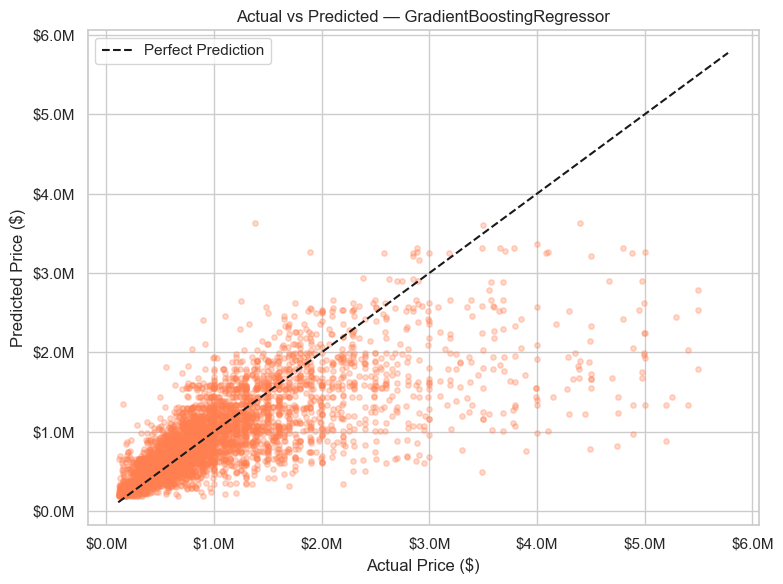

In [12]:
# ── Actual vs Predicted Plot ─────────────────────
plt.figure(figsize=(8, 6))
plt.scatter(y_real, preds_real, alpha=0.3, color="coral", s=15)
mn = min(y_real.min(), preds_real.min()) * 0.95
mx = max(y_real.max(), preds_real.max()) * 1.05
plt.plot([mn, mx], [mn, mx], "k--", lw=1.5, label="Perfect Prediction")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title(f"Actual vs Predicted — {best_name}")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
plt.legend()
plt.tight_layout()
plt.savefig("../plots/16_actual_vs_predicted.png", dpi=150)
plt.show()

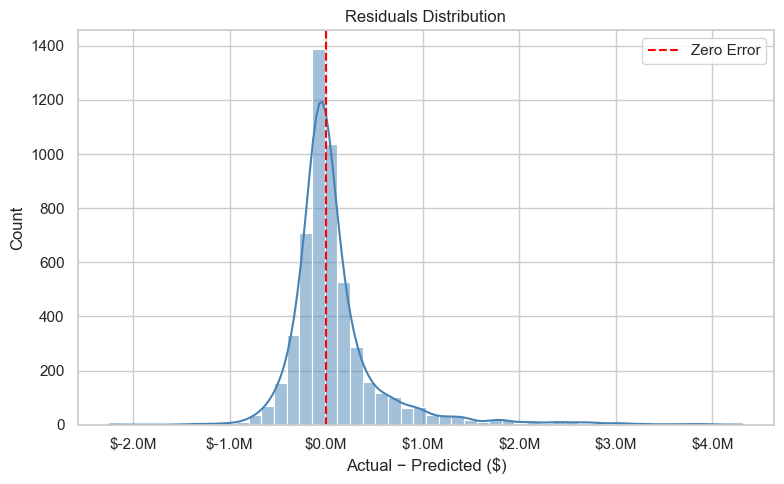

In [13]:
# ── Residuals Distribution ───────────────────────
residuals = y_real.values - preds_real

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color="steelblue", bins=50)
plt.axvline(0, color="red", linestyle="--", label="Zero Error")
plt.title("Residuals Distribution")
plt.xlabel("Actual − Predicted ($)")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
plt.legend()
plt.tight_layout()
plt.savefig("../plots/17_residuals_dist.png", dpi=150)
plt.show()

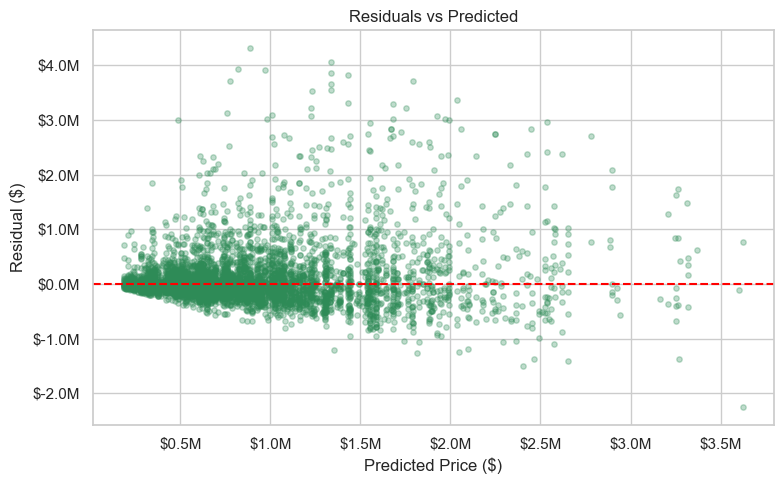

In [14]:
# ── Residuals vs Predicted ───────────────────────
plt.figure(figsize=(8, 5))
plt.scatter(preds_real, residuals, alpha=0.3, color="seagreen", s=15)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Price ($)")
plt.ylabel("Residual ($)")
plt.title("Residuals vs Predicted")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
plt.tight_layout()
plt.savefig("../plots/18_residuals_vs_predicted.png", dpi=150)
plt.show()

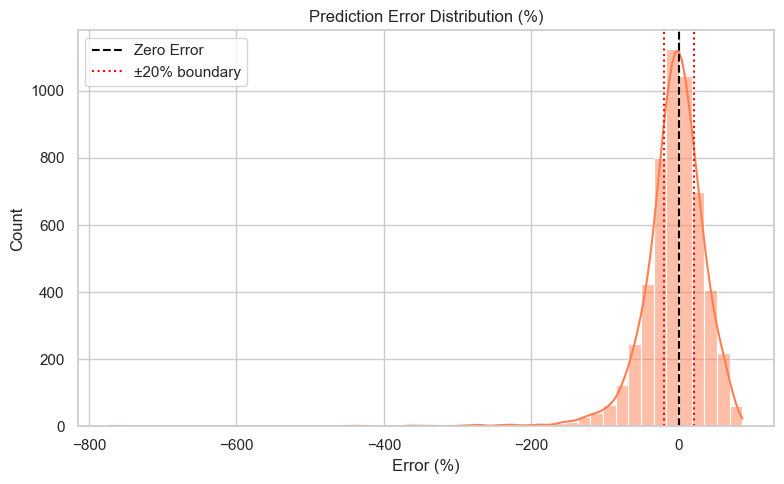

In [15]:
# ── Error % Distribution ─────────────────────────
plt.figure(figsize=(8, 5))
sns.histplot(result_df["Diff (%)"], kde=True, color="coral", bins=50)
plt.axvline(0,   color="black", linestyle="--", label="Zero Error")
plt.axvline(-20, color="red",   linestyle=":",  label="±20% boundary")
plt.axvline(20,  color="red",   linestyle=":")
plt.title("Prediction Error Distribution (%)")
plt.xlabel("Error (%)")
plt.legend()
plt.tight_layout()
plt.savefig("../plots/19_error_pct_dist.png", dpi=150)
plt.show()

In [16]:
# ── Accuracy Breakdown ───────────────────────────
within_10 = (result_df["Diff (%)"].abs() <= 10).sum()
within_20 = (result_df["Diff (%)"].abs() <= 20).sum()
within_30 = (result_df["Diff (%)"].abs() <= 30).sum()
total     = len(result_df)

print(f"\n── Prediction Accuracy Breakdown ──")
print(f"  Within ±10% : {within_10:,} / {total:,}  ({within_10/total*100:.1f}%)")
print(f"  Within ±20% : {within_20:,} / {total:,}  ({within_20/total*100:.1f}%)")
print(f"  Within ±30% : {within_30:,} / {total:,}  ({within_30/total*100:.1f}%)")


── Prediction Accuracy Breakdown ──
  Within ±10% : 1,308 / 5,330  (24.5%)
  Within ±20% : 2,501 / 5,330  (46.9%)
  Within ±30% : 3,377 / 5,330  (63.4%)


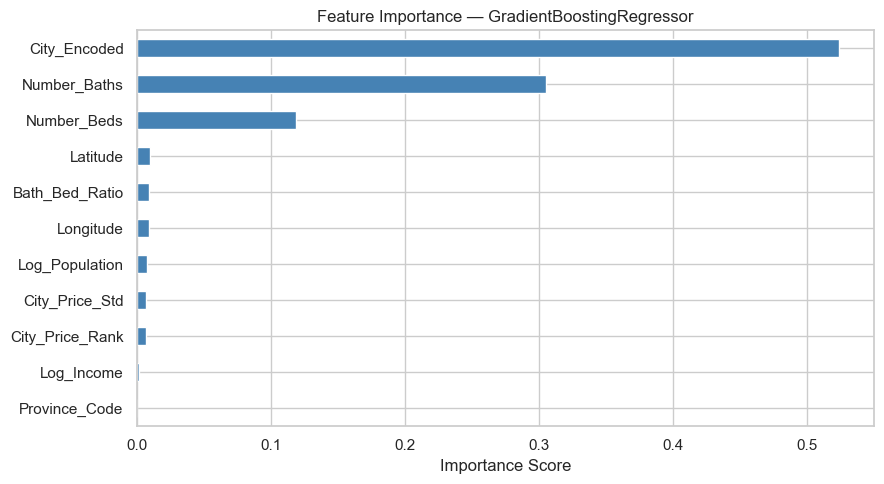

In [17]:
# ── Feature Importance ──────────────────────────
if hasattr(best_model, "feature_importances_"):
    feature_names = joblib.load("../models/model_features.pkl")
    fi = pd.Series(best_model.feature_importances_, index=feature_names).sort_values()
    plt.figure(figsize=(9, 5))
    fi.plot(kind="barh", color="steelblue")
    plt.title(f"Feature Importance — {best_name}")
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.savefig("../plots/20_feature_importance.png", dpi=150)
    plt.show()

In [5]:
# ── Test Single Row Prediction ──────────────────

# ── Load data ─────────────────────────────────────────────
df_full = pd.read_csv("../dataset/processed/housing_featured.csv")

# ── Load model ────────────────────────────────────────────
best_model = joblib.load("../models/house_price_model.pkl")
best_name  = type(best_model).__name__
print(f"✅ Model loaded: {best_name}")

city_price_map = df_full.groupby("City")["Log_Price"].median().to_dict()
city_std_map   = df_full.groupby("City")["Log_Price"].std().to_dict()
city_lat_map   = df_full.groupby("City")["Latitude"].first().to_dict()
city_lon_map   = df_full.groupby("City")["Longitude"].first().to_dict()
pop_map        = df_full.groupby("City")["Log_Population"].first().to_dict()
province_code_map = df_full.groupby("City")["Province_Code"].first().to_dict()

# ════════════════════════════════════════════════
# ── USER INPUT — only change these 5 values ──
# ════════════════════════════════════════════════
city         = "Toronto"
province     = "Ontario"
number_beds  = 3
number_baths = 2
income       = 97000
# ════════════════════════════════════════════════

# ── Auto-calculate everything else ───────────────────────
latitude        = city_lat_map.get(city)
longitude       = city_lon_map.get(city)
log_income      = np.log1p(income)
log_pop         = pop_map.get(city)
province_code   = province_code_map.get(city)
bath_bed_ratio  = number_baths / (number_beds + 1)
city_encoded    = city_price_map.get(city, np.mean(list(city_price_map.values())))
city_price_std  = city_std_map.get(city,   np.mean(list(city_std_map.values())))
city_price_rank = 0.75

# ── Validate city ─────────────────────────────────────────
if latitude is None:
    print(f"❌ City '{city}' not found. Available cities:")
    print(sorted(df_full["City"].unique().tolist()))
else:
    # ── Build input row ───────────────────────────────────
    input_data = pd.DataFrame([{
        "Number_Beds":     number_beds,
        "Number_Baths":    number_baths,
        "Latitude":        latitude,
        "Longitude":       longitude,
        "Bath_Bed_Ratio":  bath_bed_ratio,
        "Log_Income":      log_income,
        "Log_Population":  log_pop,
        "Province_Code":   province_code,
        "City_Encoded":    city_encoded,
        "City_Price_Std":  city_price_std,
        "City_Price_Rank": city_price_rank,
    }])

    # ── Predict ───────────────────────────────────────────
    log_pred = best_model.predict(input_data)[0]
    price    = np.expm1(log_pred)
    low      = price * 0.90
    high     = price * 1.10

    print(f"── Prediction Result ──────────────────")
    print(f"  City         : {city}")
    print(f"  Province     : {province}")
    print(f"  Beds         : {number_beds}")
    print(f"  Baths        : {number_baths}")
    print(f"  Income       : ${income:,}")
    print(f"  Predicted    : ${price:,.0f}")
    print(f"  Low  (−10%)  : ${low:,.0f}")
    print(f"  High (+10%)  : ${high:,.0f}")

✅ Model loaded: GradientBoostingRegressor
── Prediction Result ──────────────────
  City         : Toronto
  Province     : Ontario
  Beds         : 3
  Baths        : 2
  Income       : $97,000
  Predicted    : $1,110,868
  Low  (−10%)  : $999,781
  High (+10%)  : $1,221,954
